In [3]:
import yfinance as yf
import numpy as np
import pandas as pd
from scipy.stats import norm

# 0. Título y Autores (como comentario, ya que solo se permite un bloque de código)
# Laboratorio 4: opción americana con Longstaff–Schwartz
# Integrantes: Juan Pablo Arciniega, Santiago Sabat, Mauricio Olivares

# 1. Descargue datos históricos de un activo (SPY o AAPL vía yfinance)
# para calibrar el precio inicial S0 y estimar la volatilidad anualizada sigma_b
# mediante log-retornos históricos.
TICKER = "SPY"  # Se elige SPY como activo subyacente
# Descargar un año de datos históricos para una calibración robusta
data = yf.download(TICKER, start="2023-01-01", end="2024-01-01")

# Calibrar S0 (precio inicial) como el último precio de cierre
# Convertir a escalar usando .item()
S0 = data["Close"].iloc[-1].item()

# Estimar volatilidad anualizada (sigma_b) usando log-retornos históricos
log_returns = np.log(data["Close"] / data["Close"].shift(1))
# La volatilidad anualizada se calcula asumiendo 252 días de trading en un año
# Convertir a escalar usando .item()
sigma_b = log_returns.std().item() * np.sqrt(252)

# 2. Fije los parámetros del contrato para una opción Put
K = S0 * 0.95      # Precio de ejercicio (e.g., 95% del precio actual)
T = 1.0            # Tiempo al vencimiento en años
r = 0.05           # Tasa libre de riesgo anual (e.g., 5%)
num_paths = 10000  # Número de trayectorias de simulación
num_steps = 100    # Número de pasos de tiempo discretos para la simulación

# Cálculo del tamaño del paso de tiempo
dt = T / num_steps

# 3. Simule trayectorias discretas completas del precio del activo bajo la medida neutral al riesgo Q
# Se inicializa una matriz para almacenar las trayectorias de precios
paths = np.zeros((num_steps + 1, num_paths))
paths[0] = S0 # Todas las trayectorias comienzan en S0

# Simulación de trayectorias usando Movimiento Browniano Geométrico
for t in range(1, num_steps + 1):
    # Generar números aleatorios estándar normales para cada paso y trayectoria
    Z = np.random.normal(0, 1, num_paths)
    # Fórmula del GBM para el precio del activo en el siguiente paso de tiempo
    paths[t] = paths[t-1] * np.exp((r - 0.5 * sigma_b**2) * dt + sigma_b * np.sqrt(dt) * Z)

# 4. Implemente el algoritmo de Longstaff-Schwartz (regresión hacia atrás)
# 5. Compare en cada nodo el valor de ejercicio inmediato contra el valor de continuación
#    Actualice la regla de ejercicio temprano óptimo y determine la matriz de flujos de efectivo
#    descontados adecuadamente al momento actual.

# Inicializar los valores de la opción al vencimiento (valor intrínseco para una opción Put)
# max(K - S_T, 0)
cash_flow_received = np.maximum(K - paths[-1], 0)
# Se almacena el índice de tiempo (0 a num_steps) cuando la opción es ejercida
# Inicialmente, se asume que todas se ejercen al vencimiento
exercise_time_index = np.full(num_paths, num_steps)

# Iterar hacia atrás desde num_steps - 1 (penúltimo paso) hasta 1 (primer punto de ejercicio posible)
for t in range(num_steps - 1, 0, -1):
    # Identificar las trayectorias que están "in-the-money" en el tiempo actual 't'
    # Para una Put, está ITM si K > S_t
    in_the_money_mask = (K - paths[t] > 0)
    in_the_money_indices = np.where(in_the_money_mask)[0]

    # Solo realizar la regresión si hay trayectorias in-the-money
    if len(in_the_money_indices) > 0:
        S_t_itm = paths[t][in_the_money_indices]

        # Calcular el valor esperado de continuación para estas trayectorias ITM.
        # Estos son los flujos de efectivo de un ejercicio posterior (o al vencimiento),
        # descontados al tiempo actual 't'.
        # cash_flow_received[in_the_money_indices] contiene el flujo de caja en su respectivo exercise_time_index.
        # Se descuenta desde ese exercise_time_index hasta el tiempo actual 't'.
        y_values_for_regression = cash_flow_received[in_the_money_indices] * np.exp(-r * dt * (exercise_time_index[in_the_money_indices] - t))

        # Realizar regresión por mínimos cuadrados utilizando funciones base polinomiales (1, S_t, S_t^2).
        # np.polyfit(x, y, grado) ajusta un polinomio de grado 'grado' a los datos (x, y).
        coefficients = np.polyfit(S_t_itm, y_values_for_regression, 2) # Regresión cuadrática
        continuation_value_estimate = np.polyval(coefficients, S_t_itm)

        # Calcular el valor de ejercicio inmediato en el tiempo 't' para estas trayectorias ITM
        immediate_exercise_value_itm = np.maximum(K - S_t_itm, 0)

        # Regla de decisión: ejercer ahora si el valor de ejercicio inmediato es mayor que el valor de continuación estimado
        exercise_now_mask_for_itm = (immediate_exercise_value_itm > continuation_value_estimate)
        # Obtener los índices de las trayectorias que deben ejercerse ahora
        exercise_now_true_indices = in_the_money_indices[exercise_now_mask_for_itm]

        # Actualizar cash_flow_received y exercise_time_index para las trayectorias que se ejercen ahora
        cash_flow_received[exercise_now_true_indices] = immediate_exercise_value_itm[exercise_now_mask_for_itm]
        exercise_time_index[exercise_now_true_indices] = t # Establecer el tiempo de ejercicio al tiempo actual 't'

# Calcular el precio final de la opción americana
# Se promedian todos los flujos de efectivo, cada uno descontado desde su propio tiempo de ejercicio hasta t=0
american_option_price = np.mean(cash_flow_received * np.exp(-r * dt * exercise_time_index))


# 6. Calcule de forma paralela el valor de la opción Europea comparable
# (usando las mismas trayectorias o mediante la fórmula cerrada de Black-Scholes).
# Se utiliza la fórmula cerrada de Black-Scholes para una opción Put Europea.

# Cálculo de d1 y d2, parámetros clave en la fórmula de Black-Scholes
d1 = (np.log(S0 / K) + (r + 0.5 * sigma_b**2) * T) / (sigma_b * np.sqrt(T))
d2 = d1 - sigma_b * np.sqrt(T)

# Fórmula de Black-Scholes para una opción Put
european_option_price = K * np.exp(-r * T) * norm.cdf(-d2) - S0 * norm.cdf(-d1)

# Impresión final: Reporte ejecutivo
print(f"--- Reporte Ejecutivo de Valuación de Opciones ---")
print(f"Activo: {TICKER}")
print(f"Precio Inicial S0: {S0:.2f}")
print(f"Volatilidad Calibrada (sigma_b): {sigma_b:.4f}")
print(f"Precio de Ejercicio (K): {K:.2f}")
print(f"Tiempo al Vencimiento (T): {T:.2f} años")
print(f"Tasa Libre de Riesgo (r): {r:.2%}")
print(f"Número de Trayectorias (num_paths): {num_paths}")
print(f"Número de Pasos de Tiempo (num_steps): {num_steps}")
print(f"--------------------------------------------------")
print(f"Precio de la Opción Americana (Longstaff-Schwartz): {american_option_price:.4f}")
print(f"Precio de la Opción Europea (Black-Scholes):        {european_option_price:.4f}")
print(f"Prima por Americanidad (Americana - Europea):      {(american_option_price - european_option_price):.4f}")
print(f"--------------------------------------------------")

# Sección de texto utilizando la función print() con texto de múltiples líneas
print("""
Este script implementa la valuación de una opción put americana utilizando el método de Longstaff-Schwartz.
Se simulan trayectorias de precios del activo subyacente bajo la medida neutral al riesgo.
Luego, se retrocede en el tiempo desde el vencimiento, decidiendo en cada paso si es óptimo ejercer la opción
o mantenerla viva, comparando el valor intrínseco con el valor de continuación estimado mediante regresión
polinomial sobre las trayectorias \"in-the-money\".

El resultado final muestra el valor de la opción americana, una opción europea comparable valorada
por Black-Scholes, y la prima de americanidad, que representa el valor de la flexibilidad
de ejercicio temprano.
""")

/tmp/ipykernel_1766/1592004932.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(TICKER, start="2023-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


--- Reporte Ejecutivo de Valuación de Opciones ---
Activo: SPY
Precio Inicial S0: 462.58
Volatilidad Calibrada (sigma_b): 0.1308
Precio de Ejercicio (K): 439.45
Tiempo al Vencimiento (T): 1.00 años
Tasa Libre de Riesgo (r): 5.00%
Número de Trayectorias (num_paths): 10000
Número de Pasos de Tiempo (num_steps): 100
--------------------------------------------------
Precio de la Opción Americana (Longstaff-Schwartz): 8.1858
Precio de la Opción Europea (Black-Scholes):        7.2236
Prima por Americanidad (Americana - Europea):      0.9622
--------------------------------------------------

Este script implementa la valuación de una opción put americana utilizando el método de Longstaff-Schwartz.
Se simulan trayectorias de precios del activo subyacente bajo la medida neutral al riesgo.
Luego, se retrocede en el tiempo desde el vencimiento, decidiendo en cada paso si es óptimo ejercer la opción
o mantenerla viva, comparando el valor intrínseco con el valor de continuación estimado mediante 

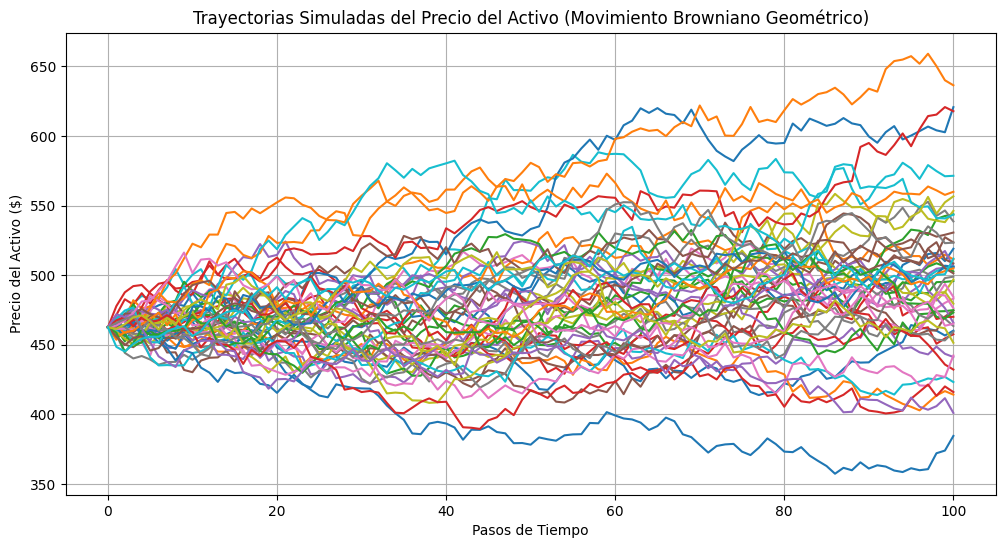

In [4]:
import matplotlib.pyplot as plt

# Número de trayectorias a visualizar para mayor claridad
num_display_paths = 50

plt.figure(figsize=(12, 6))
for i in range(min(num_display_paths, num_paths)):
    plt.plot(paths[:, i])

plt.title('Trayectorias Simuladas del Precio del Activo (Movimiento Browniano Geométrico)')
plt.xlabel('Pasos de Tiempo')
plt.ylabel('Precio del Activo ($)')
plt.grid(True)
plt.show()